# Case 3: Deliberate Movement of the Arm

## FIFA Rule (Law 12 – IFAB)
A handball offence occurs if a player **"deliberately touches the ball with the hand or arm"**, which includes **moving the arm toward the ball**.

**Reference:** IFAB – Laws of the Game, Law 12.

## Why This Is Debatable
- Arms move naturally when players run, jump, or turn.
- In slow motion, normal arm movement can look deliberate.
- It is very hard to know a player's **intention** from a video alone.
- This causes frequent arguments between players, referees, and fans.

## How AI Can Help
### Approach
- **Track the arm movement** (wrist/elbow velocity vectors across frames).
- **Track the ball movement** (ball position and velocity across frames).
- **Compare the direction** of the arm movement and the arm-to-ball direction.
- **Confirm contact** by checking if the ball's direction changed after the arm-ball proximity event.

### AI Model
- **YOLOv8-pose** for player body keypoints (arm positions across frames → motion tracking).
- **YOLOv8x** (or custom model) for ball detection and tracking.
- **Optical flow–inspired vector analysis** — comparing arm velocity direction to ball direction.

### Decision Logic
| Arm Moving Toward Ball? | Ball Direction Changed After Contact? | Decision |
|------------------------|--------------------------------------|----------|
| No | Any | **No Foul** — arm did not move toward ball |
| Yes | No | **Unlikely Foul** — arm moved toward ball but no deflection |
| Yes | Yes | **Deliberate Handball Detected** — arm moved toward ball and deflected it |

### Result
AI provides **objective motion vectors** showing whether the arm moved toward the ball, and whether the ball's trajectory changed upon contact — giving referees clear evidence of deliberate arm movement.

## Step 1 – Import Libraries
We import:
- **cv2** (OpenCV) for video/image processing
- **numpy** for numerical operations (vectors, dot products)
- **YOLO** from ultralytics for pose estimation and ball detection
- **matplotlib** for displaying frames and motion vector plots inline
- **math** for distance and angle calculations
- **collections.deque** for efficient position history tracking

In [ ]:
# installing ultralytics package
!pip install ultralytics

In [1]:
import cv2
import numpy as np
import math
from collections import deque
from ultralytics import YOLO
import matplotlib.pyplot as plt
from IPython.display import display, Image

# Display images inline in the notebook
%matplotlib inline

## Step 2 – Configuration

We define:
- **VIDEO_PATH / OUTPUT_PATH**: Input and output video paths.
- **MODEL_POSE / MODEL_BALL**: The YOLOv8 models for pose estimation and ball detection.
- **HISTORY_LENGTH**: How many past frames to keep for computing motion vectors (arm and ball).
- **BALL_DISTANCE_THRESHOLD**: Maximum pixel distance to consider ball-arm "contact".
- **ARM_TOWARD_BALL_THRESHOLD**: Cosine similarity threshold — if the arm's velocity direction aligns with the arm-to-ball direction above this value, the arm is considered to be **moving toward** the ball.
- **BALL_DIRECTION_CHANGE_THRESHOLD**: Minimum angular change (degrees) in the ball's direction after contact to confirm a deliberate deflection.

### How Deliberate Movement Is Detected

#### 1. Arm Velocity Vector
We track each arm keypoint (wrist, elbow) across consecutive frames. The **arm velocity vector** $\vec{v}_{\text{arm}}$ is the displacement from the previous frame:

$$\vec{v}_{\text{arm}} = \text{pos}_{\text{current}} - \text{pos}_{\text{previous}}$$

#### 2. Arm-to-Ball Direction
The **direction from the arm to the ball** is:

$$\vec{d}_{\text{arm→ball}} = \text{pos}_{\text{ball}} - \text{pos}_{\text{arm}}$$

#### 3. Cosine Similarity (Is the arm moving toward the ball?)
We compute the cosine similarity between the arm velocity and the arm-to-ball direction:

$$\cos(\theta) = \frac{\vec{v}_{\text{arm}} \cdot \vec{d}_{\text{arm→ball}}}{|\vec{v}_{\text{arm}}| \cdot |\vec{d}_{\text{arm→ball}}|}$$

- $\cos(\theta) > 0.5$ → arm is moving **toward** the ball (deliberate).
- $\cos(\theta) \approx 0$ → arm is moving **perpendicular** to the ball (neutral).
- $\cos(\theta) < 0$ → arm is moving **away** from the ball (not deliberate).

#### 4. Ball Direction Change (Did the ball deflect?)
After a contact event, we compare the ball's direction vector **before** and **after** the contact. If the angular change exceeds a threshold, the ball was deflected — confirming that the arm contact was meaningful.

In [2]:
# ---------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------
VIDEO_PATH = "../input.mp4"                                          # Input football video
OUTPUT_PATH = "../output/case3_deliberate_arm_movement.mp4"          # Output annotated video
MODEL_POSE = "../yolov8n-pose.pt"                                    # YOLOv8 Pose estimation model
MODEL_BALL = "../yolov8x.pt"                                         # YOLOv8 Ball detection model

# Keypoint indices (COCO format used by YOLOv8-pose)
LEFT_SHOULDER = 5
RIGHT_SHOULDER = 6
LEFT_ELBOW = 7
RIGHT_ELBOW = 8
LEFT_WRIST = 9
RIGHT_WRIST = 10
LEFT_HIP = 11
RIGHT_HIP = 12

# History length: how many past frames to keep for motion vector computation
HISTORY_LENGTH = 5

# Ball proximity threshold (in pixels)
# If the ball center is within this distance of an arm keypoint, we consider it "contact"
BALL_DISTANCE_THRESHOLD = 150

# Arm-toward-ball cosine similarity threshold
# If cos(angle between arm velocity and arm→ball direction) > this value,
# the arm is considered to be moving TOWARD the ball (deliberate movement)
ARM_TOWARD_BALL_THRESHOLD = 0.5    # cos(60°) = 0.5 → arm moving within 60° of ball direction

# Ball direction change threshold (in degrees)
# After a contact event, if the ball's direction changes by more than this angle,
# it confirms that the arm deflected the ball
BALL_DIRECTION_CHANGE_THRESHOLD = 30  # degrees

# Number of frames after contact to check for ball direction change
POST_CONTACT_WINDOW = 5

# COCO class ID for "sports ball"
# If using a custom-trained model where ball = class 0, set this to [0]
BALL_CLASS_ID = [32]   # 32 = sports ball in COCO

print("Configuration loaded.")

Configuration loaded.


## Step 3 – Helper Functions

### Ball Tracking Functions
Same as previous cases — we detect the ball center and maintain a position history.

### Arm Motion Tracking
For each arm keypoint (wrist, elbow), we store positions across frames. The **velocity vector** is computed as the average displacement over the history window:

$$\vec{v}_{\text{arm}} = \frac{1}{N-1} \sum_{i=1}^{N-1} (\text{pos}_i - \text{pos}_{i-1})$$

### Deliberate Movement Detection
The core function computes:

1. **Arm velocity vector** $\vec{v}_{\text{arm}}$ — which direction the arm is moving.
2. **Arm-to-ball direction** $\vec{d}_{\text{arm→ball}}$ — direction from the arm to the ball.
3. **Cosine similarity** between these two vectors:

$$\text{similarity} = \frac{\vec{v}_{\text{arm}} \cdot \vec{d}_{\text{arm→ball}}}{|\vec{v}_{\text{arm}}| \cdot |\vec{d}_{\text{arm→ball}}|}$$

If the similarity exceeds **ARM_TOWARD_BALL_THRESHOLD** (0.5), the arm is judged to be **moving toward** the ball.

### Ball Direction Change Detection
After a contact event, we compare the ball's velocity vector **before** and **after** the contact point. The angular change is:

$$\Delta\theta = \arccos\left(\frac{\vec{v}_{\text{before}} \cdot \vec{v}_{\text{after}}}{|\vec{v}_{\text{before}}| \cdot |\vec{v}_{\text{after}}|}\right)$$

If $\Delta\theta > 30°$, the ball was deflected — confirming the arm contact had a meaningful effect.

In [3]:
# =============================================================
# BALL DETECTION HELPERS
# =============================================================

def get_ball_center(ball_results):
    """
    Extract the ball center from detection results.
    Returns the center (cx, cy) of the highest-confidence ball detection,
    or None if no ball is detected.
    """
    if len(ball_results[0].boxes) > 0:
        best_box = None
        best_conf = 0
        for box in ball_results[0].boxes:
            conf = float(box.conf[0])
            if conf > best_conf:
                best_conf = conf
                best_box = box
        if best_box is not None:
            x1, y1, x2, y2 = best_box.xyxy[0].cpu().numpy()
            cx = (x1 + x2) / 2
            cy = (y1 + y2) / 2
            return (cx, cy)
    return None


def get_all_ball_centers(ball_results):
    """
    Extract all ball center points from detection results.
    Returns a list of (cx, cy) tuples.
    """
    centers = []
    if len(ball_results[0].boxes) > 0:
        for box in ball_results[0].boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            cx = (x1 + x2) / 2
            cy = (y1 + y2) / 2
            centers.append((cx, cy))
    return centers


def is_keypoint_valid(kp):
    """Check if a keypoint was actually detected (not at origin 0,0)."""
    return kp[0] != 0 or kp[1] != 0


# =============================================================
# DISTANCE HELPERS
# =============================================================

def min_distance_to_ball(arm_keypoints, ball_centers):
    """
    Calculate the minimum Euclidean distance between any arm keypoint
    and any detected ball center.

    Returns:
        (min_dist, closest_arm_point, closest_ball_point) or (None, None, None)
    """
    min_dist = float('inf')
    closest_arm = None
    closest_ball = None

    for kp in arm_keypoints:
        if not is_keypoint_valid(kp):
            continue
        for bc in ball_centers:
            dist = math.sqrt((kp[0] - bc[0])**2 + (kp[1] - bc[1])**2)
            if dist < min_dist:
                min_dist = dist
                closest_arm = kp
                closest_ball = bc

    if min_dist == float('inf'):
        return None, None, None
    return min_dist, closest_arm, closest_ball


# =============================================================
# MOTION VECTOR HELPERS
# =============================================================

def compute_velocity_vector(history):
    """
    Compute the average velocity vector from a position history.

    Args:
        history: list/deque of (x, y) tuples (oldest first)

    Returns:
        (vx, vy) average velocity vector, or (None, None) if insufficient data
    """
    if len(history) < 2:
        return None, None

    total_dx = 0
    total_dy = 0
    count = 0
    for i in range(1, len(history)):
        total_dx += history[i][0] - history[i - 1][0]
        total_dy += history[i][1] - history[i - 1][1]
        count += 1

    return total_dx / count, total_dy / count


def cosine_similarity(vec_a, vec_b):
    """
    Compute the cosine similarity between two 2D vectors.

    Returns:
        cosine similarity value in [-1, 1], or None if either vector is zero-length.
        +1 means same direction, 0 means perpendicular, -1 means opposite.
    """
    mag_a = math.sqrt(vec_a[0]**2 + vec_a[1]**2)
    mag_b = math.sqrt(vec_b[0]**2 + vec_b[1]**2)

    if mag_a < 1e-6 or mag_b < 1e-6:
        return None  # One of the vectors is essentially zero

    dot = vec_a[0] * vec_b[0] + vec_a[1] * vec_b[1]
    return max(-1.0, min(1.0, dot / (mag_a * mag_b)))


def angle_between_vectors(vec_a, vec_b):
    """
    Compute the angle (in degrees) between two 2D vectors.

    Returns:
        angle in degrees [0, 180], or None if either vector is zero.
    """
    cos_sim = cosine_similarity(vec_a, vec_b)
    if cos_sim is None:
        return None
    return math.degrees(math.acos(cos_sim))


def compute_ball_direction_change(ball_history, contact_index, window=POST_CONTACT_WINDOW):
    """
    Compute the change in ball direction after a contact event.

    We compare the ball's velocity vector BEFORE the contact index
    to the velocity vector AFTER the contact index.

    Args:
        ball_history: list of (frame_num, cx, cy) tuples
        contact_index: the index in ball_history where contact occurred
        window: how many positions before/after to use for vector computation

    Returns:
        direction_change_degrees: angle change in degrees, or None if insufficient data
    """
    # Need at least 2 points before and 2 points after contact
    if contact_index < 1 or contact_index >= len(ball_history) - 1:
        return None

    # Compute "before" velocity (frames leading up to contact)
    before_start = max(0, contact_index - window)
    before_positions = ball_history[before_start:contact_index + 1]
    if len(before_positions) < 2:
        return None
    before_vx, before_vy = compute_velocity_vector(
        [(p[1], p[2]) for p in before_positions]
    )
    if before_vx is None:
        return None

    # Compute "after" velocity (frames after contact)
    after_end = min(len(ball_history), contact_index + 1 + window)
    after_positions = ball_history[contact_index:after_end]
    if len(after_positions) < 2:
        return None
    after_vx, after_vy = compute_velocity_vector(
        [(p[1], p[2]) for p in after_positions]
    )
    if after_vx is None:
        return None

    # Angle between before and after velocity vectors
    return angle_between_vectors((before_vx, before_vy), (after_vx, after_vy))


# =============================================================
# DELIBERATE MOVEMENT CLASSIFICATION
# =============================================================

def classify_arm_movement(cos_sim):
    """
    Classify the arm movement based on cosine similarity
    between arm velocity and arm-to-ball direction.

    Returns:
        "TOWARD BALL"   if cos_sim > ARM_TOWARD_BALL_THRESHOLD
        "NEUTRAL"       if cos_sim is between -threshold and +threshold
        "AWAY FROM BALL" if cos_sim < -ARM_TOWARD_BALL_THRESHOLD
        "UNKNOWN"       if cos_sim is None
    """
    if cos_sim is None:
        return "UNKNOWN"
    if cos_sim > ARM_TOWARD_BALL_THRESHOLD:
        return "TOWARD BALL"
    elif cos_sim < -ARM_TOWARD_BALL_THRESHOLD:
        return "AWAY FROM BALL"
    else:
        return "NEUTRAL"


def make_deliberate_handball_decision(arm_movement, ball_deflected):
    """
    Combine arm movement classification and ball deflection into a final decision.

    Decision logic:
      - Arm toward ball + ball deflected     → "DELIBERATE HANDBALL"
      - Arm toward ball + no deflection      → "POSSIBLE HANDBALL"
      - Arm neutral/away + ball deflected    → "UNLIKELY FOUL"
      - Arm neutral/away + no deflection     → "NO FOUL"

    Returns: (decision_string, decision_color_bgr)
    """
    if arm_movement == "TOWARD BALL":
        if ball_deflected:
            return "DELIBERATE HANDBALL", (0, 0, 255)       # Red
        else:
            return "POSSIBLE HANDBALL", (0, 165, 255)       # Orange
    elif arm_movement == "NEUTRAL":
        if ball_deflected:
            return "UNLIKELY FOUL", (0, 200, 255)           # Light orange
        else:
            return "NO FOUL", (0, 255, 0)                   # Green
    else:  # AWAY FROM BALL or UNKNOWN
        return "NO FOUL", (0, 255, 0)                       # Green


def get_movement_color(movement):
    """Return a BGR color based on arm movement classification."""
    if movement == "TOWARD BALL":
        return (0, 0, 255)      # Red — arm moving toward ball
    elif movement == "NEUTRAL":
        return (0, 165, 255)    # Orange — ambiguous
    elif movement == "AWAY FROM BALL":
        return (0, 255, 0)      # Green — arm moving away
    else:
        return (200, 200, 200)  # Grey — unknown


print("Helper functions defined.")

Helper functions defined.


## Step 4 – Load the Models

We load the same **two models** as previous cases:
1. **YOLOv8n-pose** — detects 17 body keypoints per person. Used to track arm positions across frames.
2. **YOLOv8x** (or custom-trained model) — detects the football. Used to track ball position and detect direction changes.

In [4]:
# Load the YOLOv8 Pose Estimation model
print("Loading pose estimation model...")
pose_model = YOLO(MODEL_POSE)
print("Pose model loaded successfully!")

# Load the YOLOv8 Ball Detection model
print("Loading ball detection model...")
ball_model = YOLO(MODEL_BALL)
print("Ball model loaded successfully!")

Loading pose estimation model...
Pose model loaded successfully!
Loading ball detection model...
Ball model loaded successfully!


## Step 5 – Test Motion Tracking on a Few Frames

Before processing the full video, let's test the motion tracking on the first few frames to verify:
1. Ball positions are tracked correctly across frames.
2. Arm keypoint positions are tracked across frames.
3. Velocity vectors are computed correctly.
4. Cosine similarity between arm velocity and arm-to-ball direction works as expected.

We read 15 frames to build up position histories, then analyze the motion vectors on the last frame.

In [5]:
# Test motion tracking on the first 15 frames
cap = cv2.VideoCapture(VIDEO_PATH)
fps = int(cap.get(cv2.CAP_PROP_FPS))

if not cap.isOpened():
    print(f"Error: Could not open video {VIDEO_PATH}")
else:
    ball_history = deque(maxlen=HISTORY_LENGTH)
    # Track arm positions per person — key: person_idx, value: deque of (x, y)
    # For simplicity in this test, we track the wrist closest to the ball
    arm_history = deque(maxlen=HISTORY_LENGTH)

    print(f"Video FPS: {fps}")
    print(f"Motion history window: {HISTORY_LENGTH} frames")
    print("-" * 70)

    for i in range(15):
        ret, frame = cap.read()
        if not ret:
            break

        # Detect ball
        ball_results = ball_model(frame, verbose=False, conf=0.3, classes=BALL_CLASS_ID)
        ball_center = get_ball_center(ball_results)

        if ball_center is not None:
            ball_history.append(ball_center)

        # Detect poses
        pose_results = pose_model(frame, verbose=False, conf=0.5)

        # Track the arm keypoint closest to the ball (across all persons)
        closest_arm_pos = None
        if pose_results[0].keypoints is not None and len(pose_results[0].keypoints) > 0:
            keypoints = pose_results[0].keypoints.xy.cpu().numpy()
            ball_centers = get_all_ball_centers(ball_results)
            min_dist_overall = float('inf')

            for kpts in keypoints:
                for idx in [LEFT_WRIST, RIGHT_WRIST, LEFT_ELBOW, RIGHT_ELBOW]:
                    kp = kpts[idx]
                    if not is_keypoint_valid(kp):
                        continue
                    for bc in (ball_centers if ball_centers else []):
                        d = math.sqrt((kp[0] - bc[0])**2 + (kp[1] - bc[1])**2)
                        if d < min_dist_overall:
                            min_dist_overall = d
                            closest_arm_pos = (float(kp[0]), float(kp[1]))

        if closest_arm_pos is not None:
            arm_history.append(closest_arm_pos)

        # Compute velocities
        ball_vx, ball_vy = compute_velocity_vector(ball_history)
        arm_vx, arm_vy = compute_velocity_vector(arm_history)

        ball_str = f"({ball_center[0]:.0f}, {ball_center[1]:.0f})" if ball_center else "Not detected"
        arm_str = f"({closest_arm_pos[0]:.0f}, {closest_arm_pos[1]:.0f})" if closest_arm_pos else "N/A"

        # Compute cosine similarity if both velocities exist
        cos_sim = None
        if arm_vx is not None and closest_arm_pos is not None and ball_center is not None:
            arm_to_ball = (ball_center[0] - closest_arm_pos[0],
                           ball_center[1] - closest_arm_pos[1])
            cos_sim = cosine_similarity((arm_vx, arm_vy), arm_to_ball)

        cos_str = f"{cos_sim:.3f}" if cos_sim is not None else "N/A"
        movement = classify_arm_movement(cos_sim)

        print(f"Frame {i+1:2d} | Ball: {ball_str:>18s} | Arm: {arm_str:>18s} | "
              f"Cos sim: {cos_str:>6s} | {movement}")

    cap.release()

    # Compute ball velocity for display
    ball_vx, ball_vy = compute_velocity_vector(ball_history)
    arm_vx, arm_vy = compute_velocity_vector(arm_history)
    print("-" * 70)
    if ball_vx is not None:
        ball_speed = math.sqrt(ball_vx**2 + ball_vy**2) * fps
        print(f"Latest ball velocity: ({ball_vx:.1f}, {ball_vy:.1f}) px/frame → {ball_speed:.0f} px/s")
    if arm_vx is not None:
        arm_speed = math.sqrt(arm_vx**2 + arm_vy**2) * fps
        print(f"Latest arm velocity:  ({arm_vx:.1f}, {arm_vy:.1f}) px/frame → {arm_speed:.0f} px/s")

Video FPS: 29
Motion history window: 5 frames
----------------------------------------------------------------------
Frame  1 | Ball:         (192, 245) | Arm:          (73, 387) | Cos sim:    N/A | UNKNOWN
Frame  2 | Ball:         (192, 245) | Arm:          (73, 387) | Cos sim:    N/A | UNKNOWN
Frame  3 | Ball:         (199, 244) | Arm:         (144, 378) | Cos sim:  0.497 | NEUTRAL
Frame  4 | Ball:         (206, 244) | Arm:         (152, 380) | Cos sim:  0.459 | NEUTRAL
Frame  5 | Ball:         (213, 244) | Arm:         (159, 379) | Cos sim:  0.456 | NEUTRAL
Frame  6 | Ball:         (218, 244) | Arm:         (166, 377) | Cos sim:  0.460 | NEUTRAL
Frame  7 | Ball:         (223, 245) | Arm:         (104, 387) | Cos sim: -0.795 | AWAY FROM BALL
Frame  8 | Ball:         (224, 245) | Arm:         (173, 379) | Cos sim:  0.382 | NEUTRAL
Frame  9 | Ball:       Not detected | Arm:                N/A | Cos sim:    N/A | UNKNOWN
Frame 10 | Ball:         (233, 247) | Arm:                N/A | Co

## Step 6 – Single Frame Analysis with Motion Vectors

Let's visualize the motion analysis on a single frame. We read 20 frames to build history, then on the final frame we:
1. Draw the **ball's velocity vector** (orange arrow) showing the ball's travel direction.
2. Draw each player's **arm velocity vectors** (arrows from wrist/elbow) showing arm movement direction.
3. Compute the **cosine similarity** between arm velocity and arm-to-ball direction.
4. Color-code the arm arrows: **red** = moving toward ball, **orange** = neutral, **green** = moving away.
5. Draw the **arm-to-ball direction line** with the cosine similarity label.

Detected 0 ball(s) in the frame.

No persons detected in the frame.


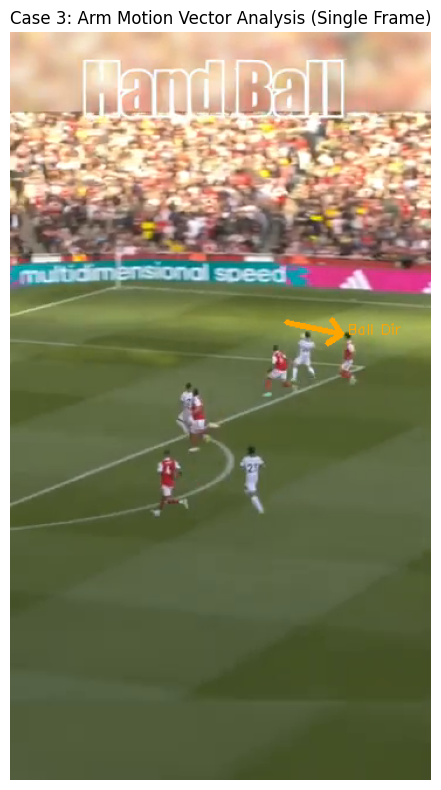

In [6]:
# Analyze a single frame with motion vector context
# We read 20 frames to build up position histories, then analyze the last one

cap = cv2.VideoCapture(VIDEO_PATH)
fps = int(cap.get(cv2.CAP_PROP_FPS))

if not cap.isOpened():
    print(f"Error: Could not open video {VIDEO_PATH}")
else:
    ball_history_full = []                         # (frame_num, cx, cy)
    # Per-person arm histories: dict of {person_idx: {kp_name: deque of (x,y)}}
    # For single-frame test, we use a simpler global tracking
    arm_histories = {}  # key: keypoint_idx, value: deque of (x, y)
    for kp_idx in [LEFT_WRIST, RIGHT_WRIST, LEFT_ELBOW, RIGHT_ELBOW]:
        arm_histories[kp_idx] = deque(maxlen=HISTORY_LENGTH)

    analysis_frame = None

    # Read 20 frames to build context
    for i in range(20):
        ret, frame = cap.read()
        if not ret:
            break

        ball_results = ball_model(frame, verbose=False, conf=0.3, classes=BALL_CLASS_ID)
        ball_center = get_ball_center(ball_results)
        if ball_center is not None:
            ball_history_full.append((i + 1, ball_center[0], ball_center[1]))

        # Track arm keypoints of the person closest to the ball
        pose_results = pose_model(frame, verbose=False, conf=0.5)
        if pose_results[0].keypoints is not None and len(pose_results[0].keypoints) > 0:
            keypoints = pose_results[0].keypoints.xy.cpu().numpy()
            # Find the person whose arm is closest to the ball
            if ball_center is not None:
                best_person = None
                best_dist = float('inf')
                for pidx, kpts in enumerate(keypoints):
                    for kp_idx in [LEFT_WRIST, RIGHT_WRIST, LEFT_ELBOW, RIGHT_ELBOW]:
                        kp = kpts[kp_idx]
                        if is_keypoint_valid(kp):
                            d = math.sqrt((kp[0] - ball_center[0])**2 + (kp[1] - ball_center[1])**2)
                            if d < best_dist:
                                best_dist = d
                                best_person = pidx

                if best_person is not None:
                    kpts = keypoints[best_person]
                    for kp_idx in [LEFT_WRIST, RIGHT_WRIST, LEFT_ELBOW, RIGHT_ELBOW]:
                        kp = kpts[kp_idx]
                        if is_keypoint_valid(kp):
                            arm_histories[kp_idx].append((float(kp[0]), float(kp[1])))

        analysis_frame = frame

    cap.release()

    if analysis_frame is None:
        print("Error: Could not read frames from video.")
    else:
        # Run both models on the analysis frame
        pose_results = pose_model(analysis_frame, verbose=False, conf=0.5)
        ball_results = ball_model(analysis_frame, verbose=False, conf=0.3, classes=BALL_CLASS_ID)

        ball_centers = get_all_ball_centers(ball_results)
        annotated = pose_results[0].plot()

        # --- Draw ball detection ---
        for box in ball_results[0].boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 165, 255), 3)
            cv2.putText(annotated, "BALL", (x1, y1 - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 165, 255), 2)

        # --- Draw ball velocity arrow ---
        if len(ball_history_full) >= 2:
            ball_positions = [(p[1], p[2]) for p in ball_history_full[-HISTORY_LENGTH:]]
            bvx, bvy = compute_velocity_vector(ball_positions)
            if bvx is not None:
                last_ball = ball_positions[-1]
                arrow_scale = 10  # Scale the velocity vector for visibility
                arrow_end = (int(last_ball[0] + bvx * arrow_scale),
                             int(last_ball[1] + bvy * arrow_scale))
                cv2.arrowedLine(annotated, (int(last_ball[0]), int(last_ball[1])),
                               arrow_end, (0, 165, 255), 3, tipLength=0.3)
                cv2.putText(annotated, "Ball Dir", (arrow_end[0] + 5, arrow_end[1]),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 165, 255), 1)

        print(f"Detected {len(ball_centers)} ball(s) in the frame.\n")

        # --- Analyze arm motion vectors ---
        if pose_results[0].keypoints is not None and len(pose_results[0].keypoints) > 0:
            keypoints = pose_results[0].keypoints.xy.cpu().numpy()
            print(f"Detected {len(keypoints)} person(s) in the frame.\n")

            for person_idx, kpts in enumerate(keypoints):
                print(f"--- Person {person_idx + 1} ---")

                for kp_idx, kp_name in [(LEFT_WRIST, "L-Wrist"), (RIGHT_WRIST, "R-Wrist"),
                                         (LEFT_ELBOW, "L-Elbow"), (RIGHT_ELBOW, "R-Elbow")]:
                    kp = kpts[kp_idx]
                    if not is_keypoint_valid(kp):
                        continue

                    history = arm_histories.get(kp_idx)
                    if history is None or len(history) < 2:
                        continue

                    # Compute arm velocity
                    avx, avy = compute_velocity_vector(history)
                    if avx is None:
                        continue

                    # Draw arm velocity arrow
                    arm_pos = (int(kp[0]), int(kp[1]))
                    arrow_scale = 10
                    arrow_end = (int(kp[0] + avx * arrow_scale),
                                 int(kp[1] + avy * arrow_scale))

                    # Compute cosine similarity to ball direction
                    cos_sim = None
                    if ball_centers:
                        # Direction from arm to closest ball
                        _, closest_arm_kp, closest_ball = min_distance_to_ball([kp], ball_centers)
                        if closest_ball is not None:
                            arm_to_ball = (closest_ball[0] - kp[0], closest_ball[1] - kp[1])
                            cos_sim = cosine_similarity((avx, avy), arm_to_ball)

                    movement = classify_arm_movement(cos_sim)
                    color = get_movement_color(movement)

                    # Draw the arm velocity arrow
                    cv2.arrowedLine(annotated, arm_pos, arrow_end, color, 2, tipLength=0.3)

                    # Draw arm-to-ball line with cosine similarity
                    if closest_ball is not None:
                        ball_pt = (int(closest_ball[0]), int(closest_ball[1]))
                        cv2.line(annotated, arm_pos, ball_pt, color, 1)
                        mid = ((arm_pos[0] + ball_pt[0]) // 2, (arm_pos[1] + ball_pt[1]) // 2)
                        cos_label = f"cos={cos_sim:.2f}" if cos_sim is not None else "cos=N/A"
                        cv2.putText(annotated, f"{kp_name}: {cos_label} {movement}",
                                   (mid[0] - 60, mid[1] - 5),
                                   cv2.FONT_HERSHEY_SIMPLEX, 0.35, color, 1)

                    arm_speed = math.sqrt(avx**2 + avy**2) * fps
                    cos_str = f"{cos_sim:.3f}" if cos_sim is not None else "N/A"
                    print(f"  {kp_name}: vel=({avx:.1f},{avy:.1f}) px/f | "
                          f"speed={arm_speed:.0f} px/s | cos_sim={cos_str} → {movement}")

                print()
        else:
            print("No persons detected in the frame.")

        # Display the annotated frame
        plt.figure(figsize=(14, 8))
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        plt.title("Case 3: Arm Motion Vector Analysis (Single Frame)")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

## Step 7 – Process the Full Video

Now we process the entire video frame-by-frame. For each frame, we:

1. **Detect the ball** and track its position history (for speed and direction change analysis).
2. **Detect all players** and track their arm keypoints (wrist, elbow) across frames.
3. **Compute arm velocity vectors** — how and where each arm is moving.
4. **Compute arm-to-ball cosine similarity** — is the arm moving toward the ball?
5. **On contact events** (ball close to arm), check if the ball's direction changed afterward.
6. **Classify the event**:
   - 🟢 **No Foul** — arm not moving toward ball, or no contact.
   - 🟠 **Possible Handball** — arm moving toward ball but no ball deflection confirmed yet.
   - 🔴 **Deliberate Handball** — arm moved toward ball AND ball direction changed after contact.
7. **Annotate the frame** with velocity arrows, cosine similarity labels, and decision banners.
8. **Save the annotated video** to output.

In [7]:
def process_video_case3(video_path, output_path, pose_model, ball_model):
    """
    Process a football video to detect handball fouls based on Case 3:
    Deliberate Movement of the Arm (FIFA Law 12).

    Tracks arm and ball motion vectors across frames. A deliberate handball is
    flagged when:
      1. The arm is moving TOWARD the ball (cosine similarity > threshold).
      2. The ball's direction CHANGES after the contact event.

    Returns:
        dict with keys:
          - 'deliberate_frames':   frames where DELIBERATE HANDBALL detected
          - 'possible_frames':     frames where POSSIBLE HANDBALL detected
          - 'unlikely_frames':     frames where UNLIKELY FOUL detected
          - 'total_frames':        total frames processed
          - 'cosine_sim_log':      list of (frame_num, cos_sim, movement) for contact events
          - 'ball_dir_change_log': list of (frame_num, angle_change_deg)
          - 'contact_events':      list of dicts with full event details
    """

    # Open input video
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video {video_path}")
        return None

    # Video properties
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = int(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Create output video writer
    out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

    print(f"Processing video: {width}x{height} @ {fps}fps ({total_frames} frames)")
    print(f"Output: {output_path}")
    print(f"Arm-toward-ball threshold: cos > {ARM_TOWARD_BALL_THRESHOLD}")
    print(f"Ball direction change threshold: > {BALL_DIRECTION_CHANGE_THRESHOLD}°")
    print(f"Ball proximity threshold: {BALL_DISTANCE_THRESHOLD}px")
    print(f"Motion history window: {HISTORY_LENGTH} frames")
    print("-" * 70)

    # ----- Tracking state -----
    frame_count = 0

    # Ball position history: list of (frame_num, cx, cy)
    ball_history_full = []
    ball_history_recent = deque(maxlen=HISTORY_LENGTH)  # For velocity computation

    # Per-person arm keypoint histories
    # Structure: dict of {person_idx: {kp_idx: deque of (x, y)}}
    # We reset per-person tracking each frame based on proximity matching
    # For simplicity, we track the "globally closest arm to ball" across persons
    global_arm_histories = {}
    for kp_idx in [LEFT_WRIST, RIGHT_WRIST, LEFT_ELBOW, RIGHT_ELBOW]:
        global_arm_histories[kp_idx] = deque(maxlen=HISTORY_LENGTH)

    # ----- Result logs -----
    deliberate_frames = []
    possible_frames = []
    unlikely_frames = []
    cosine_sim_log = []           # (frame_num, cos_sim, movement)
    ball_dir_change_log = []      # (frame_num, angle_change_deg)
    contact_events = []           # Full event details

    # Track recent contact events for deferred ball-direction-change analysis
    pending_contacts = []  # (contact_frame_num, ball_history_index_at_contact)

    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        frame_count += 1
        if frame_count % 30 == 0:
            print(f"Processing frame {frame_count}/{total_frames}...")

        # ---- Run AI models ----
        pose_results = pose_model(frame, verbose=False, conf=0.5)
        ball_results = ball_model(frame, verbose=False, conf=0.3, classes=BALL_CLASS_ID)

        # ---- Track ball ----
        ball_center = get_ball_center(ball_results)
        if ball_center is not None:
            ball_history_full.append((frame_count, ball_center[0], ball_center[1]))
            ball_history_recent.append(ball_center)

        ball_centers = get_all_ball_centers(ball_results)

        # ---- Track arm keypoints (closest person to ball) ----
        if pose_results[0].keypoints is not None and len(pose_results[0].keypoints) > 0:
            keypoints = pose_results[0].keypoints.xy.cpu().numpy()

            # Find the person whose arm is closest to the ball
            if ball_center is not None:
                best_person = None
                best_dist = float('inf')
                for pidx, kpts in enumerate(keypoints):
                    for kp_idx in [LEFT_WRIST, RIGHT_WRIST, LEFT_ELBOW, RIGHT_ELBOW]:
                        kp = kpts[kp_idx]
                        if is_keypoint_valid(kp):
                            d = math.sqrt((kp[0] - ball_center[0])**2 + (kp[1] - ball_center[1])**2)
                            if d < best_dist:
                                best_dist = d
                                best_person = pidx

                if best_person is not None:
                    kpts = keypoints[best_person]
                    for kp_idx in [LEFT_WRIST, RIGHT_WRIST, LEFT_ELBOW, RIGHT_ELBOW]:
                        kp = kpts[kp_idx]
                        if is_keypoint_valid(kp):
                            global_arm_histories[kp_idx].append((float(kp[0]), float(kp[1])))

        # ---- Start annotated frame ----
        annotated_frame = pose_results[0].plot()

        # Draw ball detections
        for box in ball_results[0].boxes:
            bx1, by1, bx2, by2 = map(int, box.xyxy[0])
            cv2.rectangle(annotated_frame, (bx1, by1), (bx2, by2), (0, 165, 255), 3)
            cv2.putText(annotated_frame, "BALL", (bx1, by1 - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 165, 255), 2)

        # Draw ball velocity arrow
        if len(ball_history_recent) >= 2:
            bvx, bvy = compute_velocity_vector(ball_history_recent)
            if bvx is not None and ball_center is not None:
                arrow_scale = 8
                b_arrow_end = (int(ball_center[0] + bvx * arrow_scale),
                               int(ball_center[1] + bvy * arrow_scale))
                cv2.arrowedLine(annotated_frame,
                               (int(ball_center[0]), int(ball_center[1])),
                               b_arrow_end, (0, 165, 255), 2, tipLength=0.3)

        # ---- Frame-level decision ----
        frame_decision = "NO FOUL"
        frame_decision_color = (0, 255, 0)
        frame_best_cos_sim = None

        # ---- Analyze arm motion for each detected person ----
        if pose_results[0].keypoints is not None and len(pose_results[0].keypoints) > 0:
            keypoints = pose_results[0].keypoints.xy.cpu().numpy()

            for person_idx, kpts in enumerate(keypoints):
                for kp_idx, kp_name in [(LEFT_WRIST, "LW"), (RIGHT_WRIST, "RW"),
                                         (LEFT_ELBOW, "LE"), (RIGHT_ELBOW, "RE")]:
                    kp = kpts[kp_idx]
                    if not is_keypoint_valid(kp):
                        continue

                    # Get arm velocity from history
                    history = global_arm_histories.get(kp_idx)
                    if history is None or len(history) < 2:
                        continue

                    avx, avy = compute_velocity_vector(history)
                    if avx is None:
                        continue

                    arm_speed = math.sqrt(avx**2 + avy**2)
                    if arm_speed < 0.5:
                        continue  # Arm essentially stationary — skip

                    # Draw arm velocity arrow
                    arm_pos = (int(kp[0]), int(kp[1]))
                    arrow_scale = 8
                    a_arrow_end = (int(kp[0] + avx * arrow_scale),
                                   int(kp[1] + avy * arrow_scale))

                    # Compute cosine similarity with arm-to-ball direction
                    cos_sim = None
                    dist_to_ball = None
                    closest_ball_pt = None

                    if ball_centers:
                        d, arm_pt, ball_pt = min_distance_to_ball([kp], ball_centers)
                        if d is not None:
                            dist_to_ball = d
                            closest_ball_pt = ball_pt
                            arm_to_ball = (ball_pt[0] - kp[0], ball_pt[1] - kp[1])
                            cos_sim = cosine_similarity((avx, avy), arm_to_ball)

                    movement = classify_arm_movement(cos_sim)
                    color = get_movement_color(movement)

                    # Draw arm velocity arrow (color-coded by movement)
                    cv2.arrowedLine(annotated_frame, arm_pos, a_arrow_end, color, 2, tipLength=0.3)

                    # ---- Contact event? Ball close to arm? ----
                    if dist_to_ball is not None and dist_to_ball < BALL_DISTANCE_THRESHOLD:
                        # This is a contact event!
                        ball_pt_int = (int(closest_ball_pt[0]), int(closest_ball_pt[1]))

                        # Draw arm-to-ball line
                        cv2.line(annotated_frame, arm_pos, ball_pt_int, color, 2)
                        mid = ((arm_pos[0] + ball_pt_int[0]) // 2,
                               (arm_pos[1] + ball_pt_int[1]) // 2)
                        cos_label = f"cos={cos_sim:.2f}" if cos_sim is not None else "cos=N/A"
                        cv2.putText(annotated_frame, f"{kp_name}: {cos_label}",
                                   (mid[0] - 40, mid[1] - 8),
                                   cv2.FONT_HERSHEY_SIMPLEX, 0.35, color, 1)
                        cv2.putText(annotated_frame, movement,
                                   (mid[0] - 40, mid[1] + 10),
                                   cv2.FONT_HERSHEY_SIMPLEX, 0.35, color, 1)

                        # Highlight the arm keypoint
                        cv2.circle(annotated_frame, arm_pos, 8, color, -1)

                        # Log the cosine similarity
                        if cos_sim is not None:
                            cosine_sim_log.append((frame_count, cos_sim, movement))

                        # Check for ball direction change (using full history)
                        ball_deflected = False
                        if len(ball_history_full) >= 3:
                            # Find the index of the current frame in ball history
                            contact_idx = len(ball_history_full) - 1
                            dir_change = compute_ball_direction_change(
                                ball_history_full, contact_idx, POST_CONTACT_WINDOW
                            )
                            if dir_change is not None:
                                ball_dir_change_log.append((frame_count, dir_change))
                                if dir_change > BALL_DIRECTION_CHANGE_THRESHOLD:
                                    ball_deflected = True
                                    # Draw deflection indicator
                                    cv2.putText(annotated_frame,
                                               f"Ball deflected: {dir_change:.0f} deg",
                                               (mid[0] - 60, mid[1] + 28),
                                               cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0, 0, 255), 1)

                        # Store pending contact for deferred analysis
                        pending_contacts.append({
                            'frame': frame_count,
                            'ball_hist_idx': len(ball_history_full) - 1,
                            'cos_sim': cos_sim,
                            'movement': movement,
                            'dist': dist_to_ball,
                        })

                        # Make decision
                        decision, dec_color = make_deliberate_handball_decision(movement, ball_deflected)

                        # Log event
                        contact_events.append({
                            'frame': frame_count,
                            'keypoint': kp_name,
                            'cos_sim': cos_sim,
                            'movement': movement,
                            'ball_dist': dist_to_ball,
                            'ball_deflected': ball_deflected,
                            'direction_change': dir_change if len(ball_history_full) >= 3 else None,
                            'decision': decision,
                        })

                        # Escalate frame decision
                        if decision == "DELIBERATE HANDBALL":
                            frame_decision = "DELIBERATE HANDBALL"
                            frame_decision_color = (0, 0, 255)
                            frame_best_cos_sim = cos_sim
                        elif decision == "POSSIBLE HANDBALL" and frame_decision != "DELIBERATE HANDBALL":
                            frame_decision = "POSSIBLE HANDBALL"
                            frame_decision_color = (0, 165, 255)
                            frame_best_cos_sim = cos_sim
                        elif decision == "UNLIKELY FOUL" and frame_decision not in ["DELIBERATE HANDBALL", "POSSIBLE HANDBALL"]:
                            frame_decision = "UNLIKELY FOUL"
                            frame_decision_color = (0, 200, 255)

        # ---- Draw frame-level decision banner ----
        if frame_decision == "DELIBERATE HANDBALL":
            deliberate_frames.append(frame_count)
            cv2.putText(annotated_frame, "DELIBERATE HANDBALL", (20, 40),
                       cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 3)
            cos_str = f"cos={frame_best_cos_sim:.2f}" if frame_best_cos_sim is not None else ""
            cv2.putText(annotated_frame,
                       f"Arm moved toward ball {cos_str} + Ball deflected",
                       (20, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
        elif frame_decision == "POSSIBLE HANDBALL":
            possible_frames.append(frame_count)
            cv2.putText(annotated_frame, "POSSIBLE HANDBALL", (20, 40),
                       cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 165, 255), 3)
            cos_str = f"cos={frame_best_cos_sim:.2f}" if frame_best_cos_sim is not None else ""
            cv2.putText(annotated_frame,
                       f"Arm moving toward ball {cos_str}",
                       (20, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 165, 255), 2)
        elif frame_decision == "UNLIKELY FOUL":
            unlikely_frames.append(frame_count)

        # Write annotated frame
        out.write(annotated_frame)

    # ---- Post-processing: check pending contacts for deferred direction changes ----
    # Re-evaluate contacts once full ball history is available
    for pc in pending_contacts:
        if pc['ball_hist_idx'] + POST_CONTACT_WINDOW < len(ball_history_full):
            dir_change = compute_ball_direction_change(
                ball_history_full, pc['ball_hist_idx'], POST_CONTACT_WINDOW
            )
            if dir_change is not None and dir_change > BALL_DIRECTION_CHANGE_THRESHOLD:
                if pc['movement'] == "TOWARD BALL" and pc['frame'] not in deliberate_frames:
                    deliberate_frames.append(pc['frame'])
                    # Remove from possible if it was there
                    if pc['frame'] in possible_frames:
                        possible_frames.remove(pc['frame'])

    # Sort frame lists
    deliberate_frames.sort()
    possible_frames.sort()
    unlikely_frames.sort()

    # Cleanup
    cap.release()
    out.release()

    # Build results
    results = {
        'deliberate_frames': deliberate_frames,
        'possible_frames': possible_frames,
        'unlikely_frames': unlikely_frames,
        'total_frames': frame_count,
        'fps': fps,
        'cosine_sim_log': cosine_sim_log,
        'ball_dir_change_log': ball_dir_change_log,
        'contact_events': contact_events,
    }

    print("-" * 70)
    print(f"Done! Processed {frame_count} frames.")
    print(f"DELIBERATE HANDBALL frames: {len(deliberate_frames)}/{frame_count} ({100*len(deliberate_frames)/max(frame_count,1):.1f}%)")
    print(f"POSSIBLE HANDBALL frames:   {len(possible_frames)}/{frame_count} ({100*len(possible_frames)/max(frame_count,1):.1f}%)")
    print(f"UNLIKELY FOUL frames:       {len(unlikely_frames)}/{frame_count} ({100*len(unlikely_frames)/max(frame_count,1):.1f}%)")
    clean = frame_count - len(deliberate_frames) - len(possible_frames) - len(unlikely_frames)
    print(f"Clean frames:               {clean}/{frame_count}")
    print(f"\nOutput saved to: {output_path}")

    if deliberate_frames:
        print(f"\n⚠️  FINAL VERDICT: DELIBERATE HANDBALL detected in {len(deliberate_frames)} frame(s)!")
        print(f"    Arm moved toward ball AND ball direction changed.")
        print(f"    Frames: {deliberate_frames[:20]}{'...' if len(deliberate_frames) > 20 else ''}")
    elif possible_frames:
        print(f"\n⚠️  FINAL VERDICT: POSSIBLE HANDBALL in {len(possible_frames)} frame(s).")
        print(f"    Arm moved toward ball but no confirmed deflection.")
        print(f"    Frames: {possible_frames[:20]}{'...' if len(possible_frames) > 20 else ''}")
    else:
        print(f"\n✅ FINAL VERDICT: NO DELIBERATE HANDBALL detected in this video.")

    return results


print("Video processing function defined.")

Video processing function defined.


## Step 8 – Run the Video Processing

Execute the full video processing pipeline. This will track arm and ball motion vectors in every frame, compute cosine similarities, detect deliberate arm movements toward the ball, and check for ball deflections.

In [8]:
# Run the full video processing pipeline for Case 3
# The returned 'results' dict contains frame logs and motion analysis data
results = process_video_case3(VIDEO_PATH, OUTPUT_PATH, pose_model, ball_model)

Processing video: 360x640 @ 29fps (253 frames)
Output: ../output/case3_deliberate_arm_movement.mp4
Arm-toward-ball threshold: cos > 0.5
Ball direction change threshold: > 30°
Ball proximity threshold: 150px
Motion history window: 5 frames
----------------------------------------------------------------------
Processing frame 30/253...
Processing frame 60/253...
Processing frame 90/253...
Processing frame 120/253...
Processing frame 150/253...
Processing frame 180/253...
Processing frame 210/253...
Processing frame 240/253...
----------------------------------------------------------------------
Done! Processed 253 frames.
DELIBERATE HANDBALL frames: 12/253 (4.7%)
POSSIBLE HANDBALL frames:   18/253 (7.1%)
UNLIKELY FOUL frames:       0/253 (0.0%)
Clean frames:               223/253

Output saved to: ../output/case3_deliberate_arm_movement.mp4

⚠️  FINAL VERDICT: DELIBERATE HANDBALL detected in 12 frame(s)!
    Arm moved toward ball AND ball direction changed.
    Frames: [86, 87, 95, 96,

## Step 9 – Visualize Motion Analysis

We plot three charts:

### Chart 1: Cosine Similarity Over Contact Events
Shows the cosine similarity between the arm velocity and the arm-to-ball direction for every frame where the ball was near a player's arm. Values:
- **> 0.5** (above red dashed line): Arm moving **toward** ball — deliberate.
- **-0.5 to 0.5**: Neutral / perpendicular movement.
- **< -0.5** (below green dashed line): Arm moving **away** from ball.

### Chart 2: Ball Direction Change at Contact Events
Shows how much the ball's direction changed (in degrees) at each contact event. Values above the **30° threshold** (red dashed line) indicate a meaningful deflection.

### Chart 3: Arm Movement Classification Distribution
A pie chart showing the proportion of contact events classified as "Toward Ball", "Neutral", and "Away from Ball".

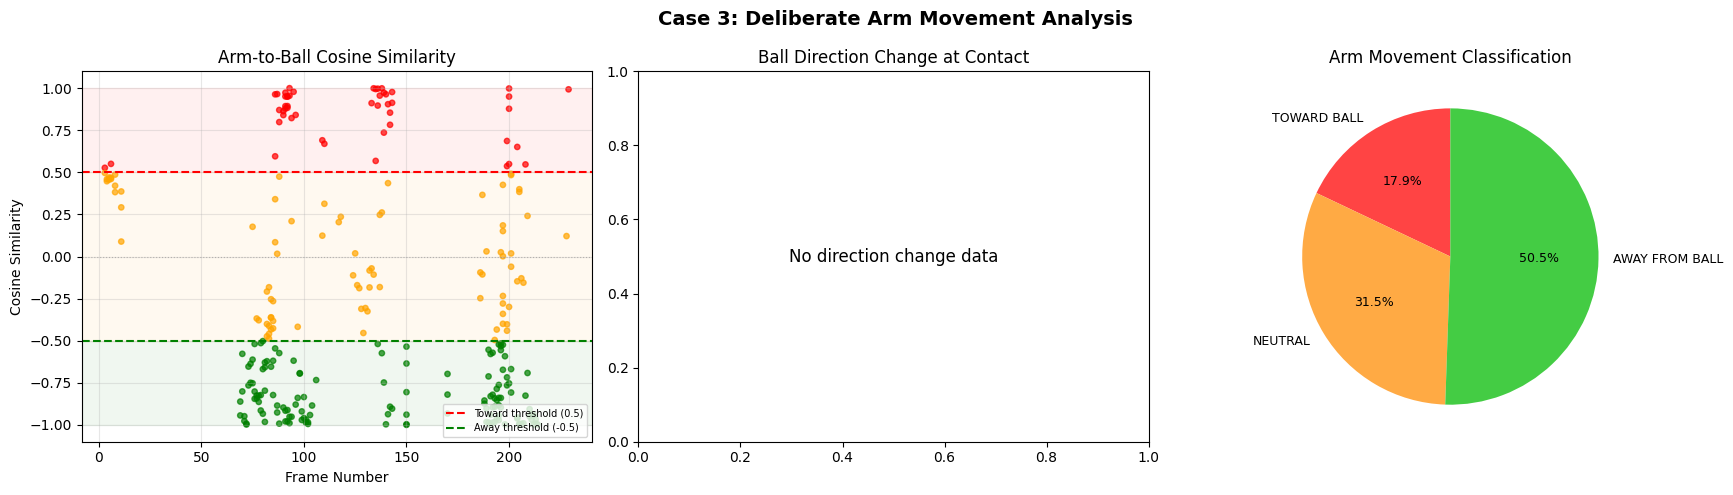


Cosine Similarity Statistics (contact events):
  Total contact events: 273
  Min:    -1.000
  Max:    1.000
  Mean:   -0.270
  Median: -0.514

Contact Event Summary:
  NO FOUL: 224 event(s)
  POSSIBLE HANDBALL: 49 event(s)


In [9]:
if results:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ---- Chart 1: Cosine Similarity Over Contact Events ----
    if results['cosine_sim_log']:
        frames_c = [x[0] for x in results['cosine_sim_log']]
        cos_vals = [x[1] for x in results['cosine_sim_log']]
        movements = [x[2] for x in results['cosine_sim_log']]

        # Color each point by movement classification
        colors = []
        for m in movements:
            if m == "TOWARD BALL":
                colors.append('red')
            elif m == "NEUTRAL":
                colors.append('orange')
            elif m == "AWAY FROM BALL":
                colors.append('green')
            else:
                colors.append('grey')

        axes[0].scatter(frames_c, cos_vals, c=colors, s=15, alpha=0.7)
        axes[0].axhline(y=ARM_TOWARD_BALL_THRESHOLD, color='red', linestyle='--',
                        linewidth=1.5, label=f'Toward threshold ({ARM_TOWARD_BALL_THRESHOLD})')
        axes[0].axhline(y=-ARM_TOWARD_BALL_THRESHOLD, color='green', linestyle='--',
                        linewidth=1.5, label=f'Away threshold (-{ARM_TOWARD_BALL_THRESHOLD})')
        axes[0].axhline(y=0, color='grey', linestyle=':', linewidth=0.8, alpha=0.5)

        # Color zones
        axes[0].axhspan(ARM_TOWARD_BALL_THRESHOLD, 1.0, alpha=0.06, color='red')
        axes[0].axhspan(-ARM_TOWARD_BALL_THRESHOLD, ARM_TOWARD_BALL_THRESHOLD, alpha=0.06, color='orange')
        axes[0].axhspan(-1.0, -ARM_TOWARD_BALL_THRESHOLD, alpha=0.06, color='green')

        axes[0].set_xlabel('Frame Number')
        axes[0].set_ylabel('Cosine Similarity')
        axes[0].set_title('Arm-to-Ball Cosine Similarity')
        axes[0].set_ylim(-1.1, 1.1)
        axes[0].legend(fontsize=7, loc='lower right')
        axes[0].grid(True, alpha=0.3)
    else:
        axes[0].text(0.5, 0.5, 'No contact events', ha='center', va='center',
                    transform=axes[0].transAxes, fontsize=12)
        axes[0].set_title('Arm-to-Ball Cosine Similarity')

    # ---- Chart 2: Ball Direction Change at Contact Events ----
    if results['ball_dir_change_log']:
        frames_d = [x[0] for x in results['ball_dir_change_log']]
        dir_changes = [x[1] for x in results['ball_dir_change_log']]

        axes[1].bar(frames_d, dir_changes, width=max(1, len(frames_d)//50 + 1),
                   color='steelblue', alpha=0.7, edgecolor='white')
        axes[1].axhline(y=BALL_DIRECTION_CHANGE_THRESHOLD, color='red', linestyle='--',
                        linewidth=2, label=f'Deflection threshold ({BALL_DIRECTION_CHANGE_THRESHOLD}°)')
        axes[1].axhspan(BALL_DIRECTION_CHANGE_THRESHOLD, max(dir_changes) * 1.1 if dir_changes else 180,
                        alpha=0.06, color='red')
        axes[1].set_xlabel('Frame Number')
        axes[1].set_ylabel('Direction Change (degrees)')
        axes[1].set_title('Ball Direction Change at Contact')
        axes[1].legend(fontsize=8)
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'No direction change data', ha='center', va='center',
                    transform=axes[1].transAxes, fontsize=12)
        axes[1].set_title('Ball Direction Change at Contact')

    # ---- Chart 3: Arm Movement Classification Distribution ----
    if results['cosine_sim_log']:
        movement_counts = {}
        for _, _, m in results['cosine_sim_log']:
            movement_counts[m] = movement_counts.get(m, 0) + 1

        labels = list(movement_counts.keys())
        sizes = list(movement_counts.values())
        pie_colors = []
        for label in labels:
            if label == "TOWARD BALL":
                pie_colors.append('#ff4444')
            elif label == "NEUTRAL":
                pie_colors.append('#ffaa44')
            elif label == "AWAY FROM BALL":
                pie_colors.append('#44cc44')
            else:
                pie_colors.append('#cccccc')

        axes[2].pie(sizes, labels=labels, colors=pie_colors, autopct='%1.1f%%',
                   startangle=90, textprops={'fontsize': 9})
        axes[2].set_title('Arm Movement Classification')
    else:
        axes[2].text(0.5, 0.5, 'No contact events', ha='center', va='center',
                    transform=axes[2].transAxes, fontsize=12)
        axes[2].set_title('Arm Movement Classification')

    plt.suptitle('Case 3: Deliberate Arm Movement Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ---- Print summary statistics ----
    if results['cosine_sim_log']:
        cos_values = [x[1] for x in results['cosine_sim_log']]
        print(f"\nCosine Similarity Statistics (contact events):")
        print(f"  Total contact events: {len(cos_values)}")
        print(f"  Min:    {min(cos_values):.3f}")
        print(f"  Max:    {max(cos_values):.3f}")
        print(f"  Mean:   {np.mean(cos_values):.3f}")
        print(f"  Median: {np.median(cos_values):.3f}")

    if results['ball_dir_change_log']:
        dc_values = [x[1] for x in results['ball_dir_change_log']]
        print(f"\nBall Direction Change Statistics:")
        print(f"  Events with direction data: {len(dc_values)}")
        print(f"  Min:    {min(dc_values):.1f}°")
        print(f"  Max:    {max(dc_values):.1f}°")
        print(f"  Mean:   {np.mean(dc_values):.1f}°")
        print(f"  Events > {BALL_DIRECTION_CHANGE_THRESHOLD}° (deflected): "
              f"{sum(1 for v in dc_values if v > BALL_DIRECTION_CHANGE_THRESHOLD)}")

    if results['contact_events']:
        print(f"\nContact Event Summary:")
        decisions = {}
        for e in results['contact_events']:
            d = e['decision']
            decisions[d] = decisions.get(d, 0) + 1
        for d, count in sorted(decisions.items()):
            print(f"  {d}: {count} event(s)")
else:
    print("No results to visualize. Run the video processing first.")

## Step 10 – Preview Output Frames

Let's preview key frames from the output video. We prioritize:
1. **Deliberate Handball frames** — shown first if any exist.
2. **Possible Handball frames** — shown if no deliberate fouls detected.
3. **Evenly sampled frames** — fallback.

Look for:
- **Colored arrows** from arm keypoints showing the arm velocity direction (red = toward ball, green = away).
- **Orange arrows** from the ball showing its travel direction.
- **Cosine similarity labels** on the arm-to-ball connecting lines.
- **Decision banners** at the top of the frame (red = deliberate, orange = possible).

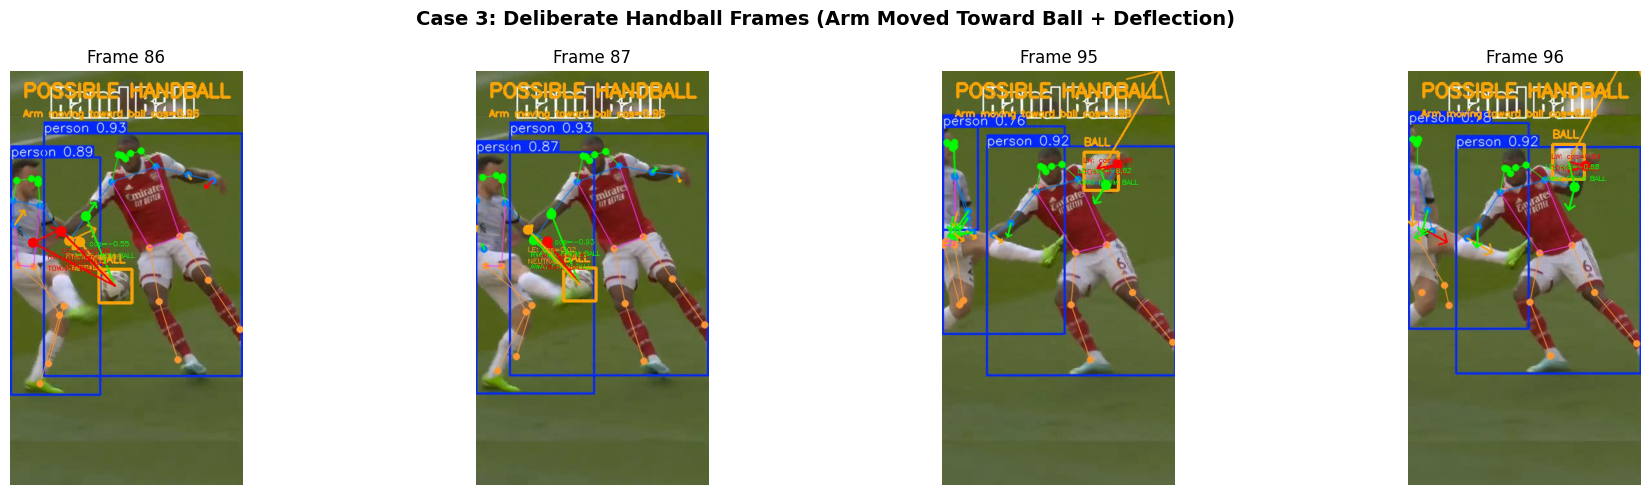

In [10]:
# Preview frames from the annotated output video
cap = cv2.VideoCapture(OUTPUT_PATH)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

if results and results['deliberate_frames']:
    sample_indices = results['deliberate_frames'][:4]
    title = "Case 3: Deliberate Handball Frames (Arm Moved Toward Ball + Deflection)"
elif results and results['possible_frames']:
    sample_indices = results['possible_frames'][:4]
    title = "Case 3: Possible Handball Frames (Arm Moving Toward Ball)"
elif results and results['unlikely_frames']:
    sample_indices = results['unlikely_frames'][:4]
    title = "Case 3: Unlikely Foul Frames"
else:
    sample_indices = [int(total * i / 4) for i in range(4)]
    title = "Case 3: Sample Frames (No Deliberate Handball Detected)"

n = min(len(sample_indices), 4)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
if n == 1:
    axes = [axes]

for i, frame_idx in enumerate(sample_indices[:n]):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx - 1)  # frame_idx is 1-based
    ret, frame = cap.read()
    if ret:
        axes[i].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"Frame {frame_idx}")
        axes[i].axis('off')

cap.release()
plt.suptitle(title, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

### What This Notebook Does
This notebook implements **Case 3** of handball foul detection: detecting when a player **deliberately moves their arm toward the ball** (FIFA Law 12 – IFAB). It goes beyond static arm position (Case 1) and reaction time (Case 2) by analyzing the **motion** of both the arm and the ball.

### How It Works — Motion Vector Analysis

1. **Arm Motion Tracking**: For each frame, we track the positions of arm keypoints (wrists, elbows) from YOLOv8-pose across a sliding window of frames. The **arm velocity vector** is computed as the average displacement per frame.

2. **Ball Motion Tracking**: Similarly, the ball's position is tracked across frames to compute its velocity vector and direction.

3. **Cosine Similarity — Is the arm moving toward the ball?**

$$\cos(\theta) = \frac{\vec{v}_{\text{arm}} \cdot \vec{d}_{\text{arm→ball}}}{|\vec{v}_{\text{arm}}| \cdot |\vec{d}_{\text{arm→ball}}|}$$

   - $\cos > 0.5$: Arm is moving **toward the ball** (within 60° of the ball direction) — suspicious.
   - $\cos \approx 0$: Arm movement is perpendicular — neutral.
   - $\cos < -0.5$: Arm is moving **away** from the ball — not deliberate.

4. **Ball Deflection Confirmation**: After a contact event, we compare the ball's velocity vector before and after contact. If the ball's direction changes by more than **30°**, it confirms the arm deflected the ball.

5. **Combined Decision**:

| Arm Moving Toward Ball? | Ball Deflected? | Decision |
|------------------------|-----------------|----------|
| Yes ($\cos > 0.5$) | Yes ($\Delta\theta > 30°$) | **Deliberate Handball** |
| Yes ($\cos > 0.5$) | No | **Possible Handball** |
| No / Neutral | Yes | **Unlikely Foul** |
| No / Neutral | No | **No Foul** |

### Visual Output
- **Red arrows** from arm keypoints — arm moving toward ball (deliberate).
- **Orange arrows** — arm movement is neutral/ambiguous.
- **Green arrows** — arm moving away from ball (not deliberate).
- **Orange arrows** from ball — ball velocity direction.
- **Cosine similarity labels** on arm-to-ball lines.
- **Ball deflection indicators** when direction change exceeds threshold.
- **Decision banners** at the top of each frame.

### Limitations
- Pose keypoint tracking across frames uses proximity-based matching, not true multi-object tracking (identity switches possible).
- The cosine similarity is sensitive to small, noisy arm movements — thresholds mitigate this by ignoring very slow arm motion (< 0.5 px/frame).
- The ball direction change analysis requires reliable ball detection in consecutive frames; gaps in detection reduce accuracy.
- All measurements are in 2D pixel space — 3D arm movements toward/away from the camera are not captured.

### How This Helps a Referee
Instead of subjectively judging whether a player "moved their arm deliberately," this system provides:
1. **Arm velocity vectors** — objective measurement of arm movement direction and speed.
2. **Cosine similarity** — a numerical score showing whether the arm moved toward the ball ($+1$ = directly toward, $0$ = perpendicular, $-1$ = directly away).
3. **Ball deflection angle** — confirms whether the arm contact actually changed the ball's path.
4. **Combined verdict** — flags only frames where the arm moved toward the ball AND the ball was deflected.

This gives VAR operators motion-based evidence to assess whether a handball was deliberate or incidental.